In [ ]:
# Load data
import pandas as pd

df_fasttext_aligned = pd.read_pickle('../data/words10_embeddings_fasttext_aligned.pkl')
df_fasttext = pd.read_pickle('../data/words10_embeddings_fasttext.pkl')
df_para = pd.read_pickle('../data/words10_embeddings_paraphrase-multilingual-MiniLM-L12-v2.pkl')
df_labse = pd.read_pickle('../data/words10_embeddings_LaBSE.pkl')

In [12]:
model_mapping = {
    'gpt_53_chat':'GPT-5.3 Chat',
    'grok_41': 'Grok 4.1',
    'sonnet_46':'Sonnet 4.6',
    'deepseek_v32':'DeepSeek-V3.2',
    'gemini_3':'Gemini 3',
    'gwen_35_plus':'Qwen3.5-Plus',
    'human':'Human',
    'mistral-medium':'mistral-medium',
    'mistral-large-2402':'mistral-large-2402',
    'mistral-small-2402':'mistral-small-2402',
    'trinity_mini':'Trinity-Mini',
    'glm_45_air':'GLM-4.5-Air'
}
    

In [13]:
df_fasttext_aligned['model'] = df_fasttext_aligned['model'].map(model_mapping)
df_fasttext['model'] = df_fasttext['model'].map(model_mapping)
df_para['model'] = df_para['model'].map(model_mapping)
df_labse['model'] = df_labse['model'].map(model_mapping)

In [15]:
# Calculate the avarage embedding per row and save it to a new column
import numpy as np

def calculate_average_embedding(row):
    word_cols = row.index[2:]
    embeddings = [row[col] for col in word_cols]

    avg_embedding = np.mean(embeddings, axis=0)
    return avg_embedding

df_fasttext_aligned['avg_embedding'] = df_fasttext_aligned.apply(calculate_average_embedding, axis=1)
df_fasttext['avg_embedding'] = df_fasttext.apply(calculate_average_embedding, axis=1)
df_para['avg_embedding'] = df_para.apply(calculate_average_embedding, axis=1)
df_labse['avg_embedding'] = df_labse.apply(calculate_average_embedding, axis=1)

In [29]:
# Sort similarity_df by model and language
from sklearn.metrics.pairwise import cosine_similarity

similarity_df = df_fasttext_aligned.sort_values(by=['model', 'language']).reset_index(drop=True)

similarity_df_en = similarity_df.loc[similarity_df['language'] == ' english']
similarity_df_fr = similarity_df[similarity_df['language'] == ' french']

country_mapping = {
    'GPT-5.3 Chat': 'US',
    'Grok 4.1': 'US',
    'Sonnet 4.6': 'US',
    'DeepSeek-V3.2': 'China',
    'Gemini 3': 'US',
    'Qwen3.5-Plus': 'China',
    'Human': 'N/A',
    'mistral-medium': 'France',
    'mistral-large-2402': 'France',
    'mistral-small-2402': 'France',
    'Trinity-Mini': 'US',
    'GLM-4.5-Air': 'China',
}

# Add country column
similarity_df_fr['country'] = similarity_df_fr['model'].map(country_mapping)
similarity_df_fr = similarity_df_fr.sort_values(by=['country', 'model']).reset_index(drop=True)

# Calculate cosine similarity matrix
similarity_matrix_en = cosine_similarity(similarity_df_en['avg_embedding'].tolist())
similarity_matrix_fr = cosine_similarity(similarity_df_fr['avg_embedding'].tolist())

C:\Users\jipwu\AppData\Local\Temp\ipykernel_30372\2760822246.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_df_fr['country'] = similarity_df_fr['model'].map(country_mapping)


In [30]:
# Create labeled similarity matrix (French example)
sim_df_fr = pd.DataFrame(
    similarity_matrix_fr,
    index=similarity_df_fr['model'].values,
    columns=similarity_df_fr['model'].values
)

sim_df_fr.to_csv("similarity_matrix_fr.csv")

In [31]:
labels = []
last_model = None

for model in similarity_df_fr['model']:
    if model != last_model:
        labels.append(model)  # show label
        last_model = model
    else:
        labels.append('')  # hide repeated labels

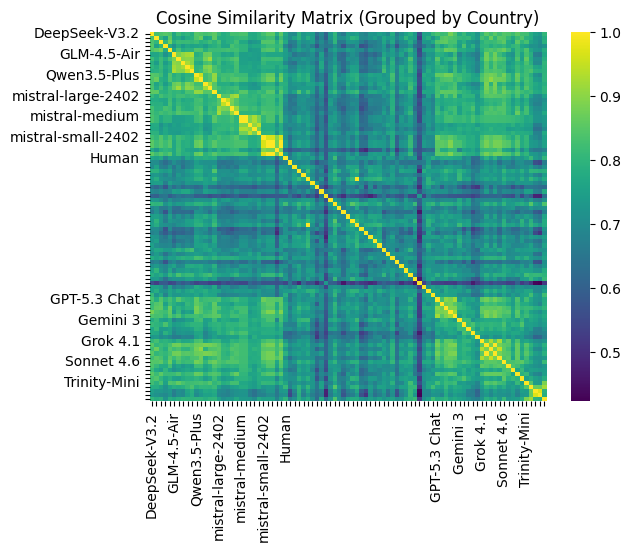

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    sim_df_fr,
    xticklabels=labels,
    yticklabels=labels,
    cmap='viridis'
)

plt.title('Cosine Similarity Matrix (Grouped by Country)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()